# Importing relevant libraries and packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import matplotlib.dates as mdates

# Data Preparation
---

## Preparation for Imran & Xinyan's Stock Data

In [2]:
data = pd.read_csv("Trading_Project_Data.csv", index_col = 0, parse_dates = True)
data.index.names = ["Date"]
data.dropna(inplace = True)
data = data.iloc[1:,:].apply(pd.to_numeric)

#Creating a separate Data Frame for each of the individual stocks
apple_data = pd.DataFrame({"Close": data["Close"], "Dividends": data["Dividends"], "High": data["High"], "Low": data["Low"], "Open":data["Open"], "Stock Splits" : data["Stock Splits"], "Volume": data["Volume"]})
amazon_data = pd.DataFrame({"Close": data["Close.1"], "Dividends": data["Dividends.1"], "High": data["High.1"], "Low": data["Low.1"], "Open":data["Open.1"], "Stock Splits" : data["Stock Splits.1"], "Volume": data["Volume.1"]})
boeing_data = pd.DataFrame({"Close": data["Close.2"], "Dividends": data["Dividends.2"], "High": data["High.2"], "Low": data["Low.2"], "Open":data["Open.2"], "Stock Splits" : data["Stock Splits.2"], "Volume": data["Volume.2"]})
caterpillar_data = pd.DataFrame({"Close": data["Close.3"], "Dividends": data["Dividends.3"], "High": data["High.3"], "Low": data["Low.3"], "Open":data["Open.3"], "Stock Splits" : data["Stock Splits.3"], "Volume": data["Volume.3"]})
chevron_data = pd.DataFrame({"Close": data["Close.4"], "Dividends": data["Dividends.4"], "High": data["High.4"], "Low": data["Low.4"], "Open":data["Open.4"], "Stock Splits" : data["Stock Splits.4"], "Volume": data["Volume.4"]})
google_data = pd.DataFrame({"Close": data["Close.5"], "Dividends": data["Dividends.5"], "High": data["High.5"], "Low": data["Low.5"], "Open":data["Open.5"], "Stock Splits" : data["Stock Splits.5"], "Volume": data["Volume.5"]})
goldman_data = pd.DataFrame({"Close": data["Close.6"], "Dividends": data["Dividends.6"], "High": data["High.6"], "Low": data["Low.6"], "Open":data["Open.6"], "Stock Splits" : data["Stock Splits.6"], "Volume": data["Volume.6"]})
jj_data = pd.DataFrame({"Close": data["Close.7"], "Dividends": data["Dividends.7"], "High": data["High.7"], "Low": data["Low.7"], "Open":data["Open.7"], "Stock Splits" : data["Stock Splits.7"], "Volume": data["Volume.7"]})
jpm_data = pd.DataFrame({"Close": data["Close.8"], "Dividends": data["Dividends.8"], "High": data["High.8"], "Low": data["Low.8"], "Open":data["Open.8"], "Stock Splits" : data["Stock Splits.8"], "Volume": data["Volume.8"]})
cococola_data = pd.DataFrame({"Close": data["Close.9"], "Dividends": data["Dividends.9"], "High": data["High.9"], "Low": data["Low.9"], "Open":data["Open.9"], "Stock Splits" : data["Stock Splits.9"], "Volume": data["Volume.9"]})
macd_data = pd.DataFrame({"Close": data["Close.10"], "Dividends": data["Dividends.10"], "High": data["High.10"], "Low": data["Low.10"], "Open":data["Open.10"], "Stock Splits" : data["Stock Splits.10"], "Volume": data["Volume.10"]})
microsoft_data = pd.DataFrame({"Close": data["Close.11"], "Dividends": data["Dividends.11"], "High": data["High.11"], "Low": data["Low.11"], "Open":data["Open.11"], "Stock Splits" : data["Stock Splits.11"], "Volume": data["Volume.11"]})
nike_data = pd.DataFrame({"Close": data["Close.12"], "Dividends": data["Dividends.12"], "High": data["High.12"], "Low": data["Low.12"], "Open":data["Open.12"], "Stock Splits" : data["Stock Splits.12"], "Volume": data["Volume.12"]})
nvidia_data = pd.DataFrame({"Close": data["Close.13"], "Dividends": data["Dividends.13"], "High": data["High.13"], "Low": data["Low.13"], "Open":data["Open.13"], "Stock Splits" : data["Stock Splits.13"], "Volume": data["Volume.13"]})
pfizer_data = pd.DataFrame({"Close": data["Close.14"], "Dividends": data["Dividends.14"], "High": data["High.14"], "Low": data["Low.14"], "Open":data["Open.14"], "Stock Splits" : data["Stock Splits.14"], "Volume": data["Volume.14"]})
sofi_data = pd.DataFrame({"Close": data["Close.15"], "Dividends": data["Dividends.15"], "High": data["High.15"], "Low": data["Low.15"], "Open":data["Open.15"], "Stock Splits" : data["Stock Splits.15"], "Volume": data["Volume.15"]})
tesla_data = pd.DataFrame({"Close": data["Close.16"], "Dividends": data["Dividends.16"], "High": data["High.16"], "Low": data["Low.16"], "Open":data["Open.16"], "Stock Splits" : data["Stock Splits.16"], "Volume": data["Volume.16"]})
uh_data = pd.DataFrame({"Close": data["Close.17"], "Dividends": data["Dividends.17"], "High": data["High.17"], "Low": data["Low.17"], "Open":data["Open.17"], "Stock Splits" : data["Stock Splits.17"], "Volume": data["Volume.17"]})
walmart_data = pd.DataFrame({"Close": data["Close.18"], "Dividends": data["Dividends.18"], "High": data["High.18"], "Low": data["Low.18"], "Open":data["Open.18"], "Stock Splits" : data["Stock Splits.18"], "Volume": data["Volume.18"]})
exxon_data = pd.DataFrame({"Close": data["Close.19"], "Dividends": data["Dividends.19"], "High": data["High.19"], "Low": data["Low.19"], "Open":data["Open.19"], "Stock Splits" : data["Stock Splits.19"], "Volume": data["Volume.19"]})

#Stocks is as array of each stock's Data Frame
stocks = [apple_data, amazon_data, boeing_data,  caterpillar_data, chevron_data, google_data, goldman_data, jj_data, jpm_data, cococola_data, macd_data, microsoft_data, nike_data, nvidia_data, pfizer_data, sofi_data, tesla_data, uh_data, walmart_data, exxon_data]

stock_names = ["apple_data", "amazon_data", "boeing_data", "caterpillar_data", "chevron_data", "google_data", "goldman_data", "jj_data", "jpm_data", "cococola_data", "macd_data", "microsoft_data", "nike_data", "nvidia_data", "pfizer_data", "sofi_data", "tesla_data", "uh_data", "walmart_data", "exxon_data"]

# ===== Create Individual Stock DataFrames =====

# Define stock information (columns grouped in sets of 1)
stock_info = [
    ("apple_data", 0), ("amazon_data", 1), ("boeing_data", 2), ("caterpillar_data", 3),
    ("chevron_data", 4), ("google_data", 5), ("goldman_data", 6), ("jj_data", 7),
    ("jpm_data", 8), ("cocacola_data", 9), ("macd_data", 10), ("microsoft_data", 11),
    ("nike_data", 12), ("nvidia_data", 13), ("pfizer_data", 14), ("sofi_data", 15),
    ("tesla_data", 16), ("uh_data", 17), ("walmart_data", 18), ("exxon_data", 19)
]

# Dynamically create stock DataFrames
stocks = []
stock_names = []

for name, idx in stock_info:
    stock_df = pd.DataFrame({
        "Close": data[f"Close{'' if idx == 0 else '.' + str(idx)}"],
        "Dividends": data[f"Dividends{'' if idx == 0 else '.' + str(idx)}"],
        "High": data[f"High{'' if idx == 0 else '.' + str(idx)}"],
        "Low": data[f"Low{'' if idx == 0 else '.' + str(idx)}"],
        "Open": data[f"Open{'' if idx == 0 else '.' + str(idx)}"],
        "Stock Splits": data[f"Stock Splits{'' if idx == 0 else '.' + str(idx)}"],
        "Volume": data[f"Volume{'' if idx == 0 else '.' + str(idx)}"]
    })
    stocks.append(stock_df)
    stock_names.append(name)

# stocks -> List of individual stock DataFrames
# stock_names -> Corresponding names of the stocks


# ===== Benchmark Calculation Function =====

def benchmark(data_original):
    """
    Given a dataframe of a single stock, returns the benchmark performance in terms of 1 + R
    """
    data = data_original.copy()
    data = data.loc["1/3/2024":]
    data["Returns"] = np.log(data["Close"]/data["Close"].shift(1))

    data["Direction"] = np.where(data["Returns"] > 0, 1, -1)
    data["Position"] = np.ones(len(data))

    return np.exp(data["Returns"].sum())

## Preparation for Joshua's Stock Data

In [3]:
#Function to create MACD indicator easily
def calculate_macd(prices, slow=26, fast=12):
    exp1 = prices.ewm(span=fast, adjust=False).mean()
    exp2 = prices.ewm(span=slow, adjust=False).mean()
    macd = exp1 - exp2
    signal = macd.ewm(span=9, adjust=False).mean()
    hist = macd-signal
    return macd, signal, hist

#Function to prepare the stock data dataframe (josh)
def prepare_stock_data(ticker, external_index, indicator_lags, external_lags):
    data = yf.Ticker(ticker).history(start="2024-01-17", end="2025-01-17")[["Close"]]
    data.index = pd.to_datetime(data.index.date) #Standardise the index date format
    data = data.join(external_index)
    data["Returns"] = np.log(data["Close"] / data["Close"].shift(1))

    # Add indicators
    data['MACD'], data['MACD_Signal'], data['MACD_Hist'] = calculate_macd(data["Close"]) #function defined above

    # Shift indicators (lagging)
    data[['MACD', 'MACD_Signal', 'MACD_Hist']] = data[['MACD', 'MACD_Signal', 'MACD_Hist']].shift(indicator_lags)
    data[["External Price"]] = data[["External Price"]].shift(external_lags)

    data = data.dropna()
    data["Direction"] = np.sign(data["Returns"]).astype(int)

    data.index = data.index.strftime("%-d/%-m/%Y")  # For UNIX (macOS/Linux)
    #data.index = data.index.strftime("%#d/%#m/%Y")  # For Windows formatting

    data=data[1:] #start from row 1 onwards because first row MACD values will all be 0

    return data

#Preparing the external stock indexes to be used as features
oil_index = pd.read_excel("oil_index.xlsx", parse_dates=["Date"],index_col="Date")

commodity_index = pd.read_excel("commodity_index.xlsx", parse_dates=["Date"], index_col="Date")
commodity_index = commodity_index[::-1]

#Cleaning the index data to the same range as stock date
start= "2024-01-17"
end= "2025-01-16"

oil_index = oil_index.loc[start:end]
commodity_index = commodity_index.loc[start:end]

## Preparation for May's Stock Data

In [4]:
#Function to prepare stock data for May's strategy
data = pd.read_csv("Trading_Project_Data.csv", index_col=0, parse_dates=True)
data.index.names = ["Date"]
data.dropna(inplace=True)
data = data.iloc[1:, :].apply(pd.to_numeric)

# Define base columns and tickers
base_cols = ["Close", "Dividends", "High", "Low", "Open", "Stock Splits", "Volume"]
tickers = [
    "AAPL", "AMZN", "BA", "CAT", "CVX", "GOOGL", "GS", "JNJ", "JPM",
    "KO", "MCD", "MSFT", "NKE", "NVDA", "PFE", "SOFI", "TSLA", "UNH",
    "WMT", "XOM"
]
n_stocks = data.shape[1] // len(base_cols)

# Create dictionary of DataFrames for each stock
stock_data = {}
for i in range(n_stocks):
    cols = {}
    for col in base_cols:
        col_name = col if i == 0 else f"{col}.{i}"
        cols[col] = data[col_name]
    stock_data[tickers[i]] = pd.DataFrame(cols)

## Generating all 10 of the "Prepared" stock data for later use

In [5]:
exxon_data=prepare_stock_data("XOM",oil_index,2,1) #Josh preparation code

chevron_data=prepare_stock_data("CVX",oil_index,2,2) #Josh preparation code

caterpillar_data=prepare_stock_data("CAT",commodity_index,2,2) #Josh preparation code

unitedhealth_data=stock_data["UNH"] #May preparation code

nvidia_data=stock_data["NVDA"] #May preparation code

johnson_data=stock_data["JNJ"] #May preparation code

microsoft_data=microsoft_data #Imran & Xinyan preparation code

apple_data=apple_data #Imran & Xinyan preparation code

nike_data=nike_data #Imran & Xinyan preparation code

boeing_data=boeing_data #Imran & Xinyan preparation code

# Trading Strategies

### Imran Strategy

In [6]:
#Imran Strategy 1 (Used for Microsoft)
def imran1(data_original, return_full = False):

    data = pd.DataFrame(data_original["Close"]).copy()

    #Basic Features
    data["Returns"] = np.log(data["Close"]/data["Close"].shift(1))
    data["Direction"] = np.where(data["Returns"] > 0, 1, -1)

    #Feature Engineering the Exponential Moving Averages and some functions of them, in this case, its square
    data["EWM20"] = data["Close"].ewm(alpha = 0.30, min_periods = 20, adjust = False).mean()
    data["EWM20 sq"] = data["EWM20"]**2


    #Only need these relevant features for the model
    #Note that li refers to lagged_i day

    features = ["EWM20_l1", "EWM20_l2", "EWM20 sq_l1", "EWM20 sq_l2"]

    data["EWM20_l1"] = data["EWM20"].shift(1)
    data["EWM20_l2"] = data["EWM20"].shift(2)
    data["EWM20 sq_l1"] = data["EWM20 sq"].shift(1)
    data["EWM20 sq_l2"] = data["EWM20 sq"].shift(2)

    data.dropna(inplace = True)

    #Now, dynamically train our model
    dates1 = (data.loc["29/2/2024":].index)[:-1] #To iterate over dynamic training data
    dates2 = data.loc["29/2/2024":].index #To iterate over the dates to predict

    data_results = (data.loc["29/2/2024":]).copy()
    data_results["Predicted Close"] = np.zeros(len(data_results))
    data_results.loc["29/2/2024", "Predicted Close"] = data.loc["29/2/2024", "Close"]

    for i,d in enumerate(dates1):

        data_train = data.loc[:d].copy()

        model = LinearRegression()
        model.fit(data_train[features], data_train["Close"])

        dtp = dates2[1:][i] #dtp := date to predict

        data_topredict = pd.DataFrame(dict(data_results.loc[dtp]), index = [dtp])
        prediction = model.predict(data_topredict[features])
        data_results.loc[dtp, "Predicted Close"] = prediction

    data_results["Predicted Direction"] = data_results["Predicted Close"] - data_results["Close"].shift(1)
    data_results.dropna(inplace = True)
    data_results["Predicted Direction"] = np.where(data_results["Predicted Direction"] > 0, 1, -1)

    data_results["Strategy"] = data_results["Predicted Direction"]*data_results["Returns"]

    return np.exp(data_results["Strategy"].sum()) if not return_full else data_results

#Imran Strategy 2 (Used for Apple)
def imran2(data_original, return_full = False):

    data = pd.DataFrame(data_original["Close"]).copy()

    #Basic Features
    data["Returns"] = np.log(data["Close"]/data["Close"].shift(1))
    data["Direction"] = np.where(data["Returns"] > 0, 1, -1)

    #Feature Engineering the Exponential Moving Averages and some functions of them, in this case, its square root raise to the power 3
    # Note that i name it EWM20 sqr for convenience
    data["EWM20"] = data["Close"].ewm(alpha = 0.30, min_periods = 20, adjust = False).mean()
    data["EWM20 sqr"] = data["EWM20"]**(3/2)


    #Only need these relevant features for the model
    #Note that li refers to lagged_i day

    features = ["Close_l1","EWM20_l1","EWM20 sqr_l1"]

    data["Close_l1"] = data["Close"].shift(1)
    data["EWM20_l1"] = data["EWM20"].shift(1)
    data["EWM20 sqr_l1"] = data["EWM20 sqr"].shift(1)

    data.dropna(inplace = True)

    #Now, dynamically train our model
    dates1 = (data.loc["29/2/2024":].index)[:-1] #To iterate over dynamic training data
    dates2 = data.loc["29/2/2024":].index #To iterate over the dates to predict

    data_results = (data.loc["29/2/2024":]).copy()
    data_results["Predicted Close"] = np.zeros(len(data_results))
    data_results.loc["29/2/2024", "Predicted Close"] = data.loc["29/2/2024", "Close"]

    for i,d in enumerate(dates1):

        data_train = data.loc[:d].copy()

        model = LinearRegression()
        model.fit(data_train[features], data_train["Close"])

        dtp = dates2[1:][i] #dtp := date to predict

        data_topredict = pd.DataFrame(dict(data_results.loc[dtp]), index = [dtp])
        prediction = model.predict(data_topredict[features])
        data_results.loc[dtp, "Predicted Close"] = prediction

    data_results["Predicted Direction"] = data_results["Predicted Close"] - data_results["Close"].shift(1)
    data_results.dropna(inplace = True)
    data_results["Predicted Direction"] = np.where(data_results["Predicted Direction"] > 0, 1, -1)

    data_results["Strategy"] = data_results["Predicted Direction"]*data_results["Returns"]

    return np.exp(data_results["Strategy"].sum()) if not return_full else data_results

### Xinyan Strategy

In [7]:
def xinyan(data_original, return_full=False):
    """
    MLPClassifier-based trading strategy for Nike and Boeing using engineered features.

    Parameters:
    - data_original (DataFrame): Stock DataFrame containing 'Close' price column.
    - return_full (bool): If True, return full DataFrame with detailed results;
                          If False, return only cumulative return multiplier.

    Returns:
    - DataFrame or float: Full backtest results or cumulative return.
    """
    data = pd.DataFrame(data_original["Close"]).copy()

    # ===== Feature Engineering =====
    data["Returns"] = np.log(data["Close"] / data["Close"].shift(1))
    data["Direction"] = np.where(data["Returns"] > 0, 1, -1)
    data["Delta Returns_l1"] = data["Returns"].shift(1) - data["Returns"].shift(2)

    # EWMA features to capture fast and medium-speed trend shifts
    data["EWM_3"] = data["Delta Returns_l1"].ewm(span=3, adjust=False).mean()
    data["EWM_5"] = data["Delta Returns_l1"].ewm(span=5, adjust=False).mean()

    # Create lagged versions to prevent data leakage
    data["Returns_l1"] = data["Returns"].shift(1)
    data["Returns_l2"] = data["Returns"].shift(2)
    data["EWM_3_l1"] = data["EWM_3"].shift(1)
    data["EWM_5_l1"] = data["EWM_5"].shift(1)

    # Multiply returns and EWMA lags to capture nonlinear effects
    data["Returns_l1_EWM_3_l1"] = data["Returns_l1"] * data["EWM_3_l1"]
    data["Returns_l2_EWM_5_l1"] = data["Returns_l2"] * data["EWM_5_l1"]

    # Additional EWMA Lags
    data["EWM_3_lag"] = data["EWM_3"].shift(1)
    data["EWM_5_lag"] = data["EWM_5"].shift(1)

    features = [
        "Returns_l1", "Returns_l2",
        "EWM_3_l1", "EWM_5_l1",
        "EWM_3_lag", "EWM_5_lag",
        "Returns_l1_EWM_3_l1", "Returns_l2_EWM_5_l1",
        "Delta Returns_l1"
    ]

    data.dropna(inplace=True)

    # ===== Backtesting Setup =====
    dates1 = data.loc["29/2/2024":].index[:-1] # Training cutoff dates
    dates2 = data.loc["1/3/2024":].index # Prediction dates
    data_results = data.loc["1/3/2024":].copy()
    data_results["Predicted Direction"] = 0

    model = None
    scaler = None
    retrain_every_n=10 # Retrain model every 10 trading days
    min_train_size=20 # Minimum samples needed to train model

    for i, d in enumerate(dates1):
        # Get training data up to this day
        data_train = data.loc[:d].copy()

        # Retrain model for every n steps
        if (i % retrain_every_n == 0):
            if len(data_train) < min_train_size:
                continue  # Not enough data to train

            # Scale training features
            scaler = StandardScaler()
            model = MLPClassifier(
                hidden_layer_sizes=[64, 32],
                alpha=0.01,
                max_iter=3000,
                early_stopping=True,
                random_state=1)

            X_train_scaled = scaler.fit_transform(data_train[features])
            model.fit(X_train_scaled, data_train["Direction"])

        # Make Prediction for the Next Day
        dtp = dates2[i]
        data_topredict = data.loc[[dtp], features]
        X_pred_scaled = scaler.transform(data_topredict)
        prediction = model.predict(X_pred_scaled)
        data_results.loc[dtp, "Predicted Direction"] = prediction


    data_results.dropna(inplace=True)
    data_results["Strategy"] = data_results["Predicted Direction"] * data_results["Returns"]

    if return_full:
        return data_results
    else:
        return np.exp(data_results["Strategy"].sum())

### Josh Strategy

In [8]:
def josh(stock_data,features,return_full = False,target_col= "Direction"):

    #To facilitate with how imran and xinyan cleans the code,
    # stock_data_original will be of how imran and xinyan cleaned
    stock_data = stock_data

    train = stock_data.loc["22/1/2024":"29/2/2024"].copy() #starts on 22/1/2024 because even though my training range started from 17/1/2024, after lagging the indicators by 2 days, the training range now starts from 22/1/2024
    test = stock_data.loc["1/3/2024":"16/1/2025"].copy()

    #Training model & predict
    model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(train[features], train[target_col])

    test["Predicted Direction"] = model.predict(test[features])
    test["Strategy"] = test["Predicted Direction"] * test["Returns"]

    return np.exp(test["Strategy"].sum()) if not return_full else test

### May Strategy

In [9]:
#May's strategy
def may(ticker):
    #Map ticker symbols to their dataframes
    mapping = {
        "JNJ": jj_data, #johnson&johnson
        "UNH": uh_data, #unitedhealth group
        "NVDA": nvidia_data #nvidia
    }
    df = mapping[ticker].copy() #copy df to avoid changing original

    df['Return'] = df['Close'].pct_change() #Compute daily percentage returns from closing prices

    #Calculate 14 day RSI
    delta = df['Close'].diff() #price changes each day
    gain = delta.clip(lower=0) #only positive changes
    loss = -delta.clip(upper=0) #only negative changes (as positive values)
    avg_gain = gain.rolling(window=14).mean() #average gain over 14 days
    avg_loss = loss.rolling(window=14).mean() #average losses over 14 days
    rs = avg_gain / avg_loss #relative strength
    df['RSI'] = 100 - (100 / (1 + rs)) #RSI formula from lecture 4

    #Calculate MACD using 12 day and 26 day exponential moving averages (EMA)
    df['EMA12'] = df['Close'].ewm(span=12, adjust=False).mean() #12 day EMA
    df['EMA26'] = df['Close'].ewm(span=26, adjust=False).mean() #26 day EMA
    df['MACD'] = df['EMA12'] - df['EMA26'] #MACD line

    #Calculate 14 day average volume and volume change ratio
    df['Volume_Avg_14'] = df['Volume'].rolling(window=14).mean() #Average volume over 14 days
    df['Vol_Change'] = df['Volume'] / df['Volume_Avg_14'] - 1 #(Today's volume - 14 day average volume) / 14 day average volume

    #Drop rows that lack one of our three features
    df.dropna(subset=['RSI','MACD','Vol_Change'], inplace=True)

    #Ensure index is timezone free datetime and sort in chronological order
    df.index = pd.to_datetime(df.index, dayfirst=True).tz_localize(None)
    df.sort_index(inplace=True)

    #Define training & simulation periods
    training_start   = pd.Timestamp("2024-01-22")
    training_end   = pd.to_datetime("2024-02-29", format="%Y-%m-%d", errors="coerce")
    simulation_start = pd.Timestamp("2024-03-01")
    simulation_end   = pd.Timestamp("2025-01-16")

    #training and simulation dataframes
    df_training   = df.loc[training_start:training_end].copy()
    df_simulation = df.loc[simulation_start:simulation_end].copy()

    if df_training.empty:
        raise ValueError(f"No training data between {training_start.date()} and {training_end.date()}")
    if df_simulation.empty:
        raise ValueError(f"No simulation data between {simulation_start.date()} and {simulation_end.date()}")

    features = ['RSI', 'MACD', 'Vol_Change'] #Features and binary targets for classification
    X_train     = df_training[features] #Train features
    y_train     = df_training['Return'] #Train raw returns
    y_train_bin = (y_train > 0).astype(int) #1 if positive returns, else 0
    X_test      = df_simulation[features] #Simulation features
    y_test      = df_simulation['Return'] #Simulation raw returns
    y_test_bin  = (y_test > 0).astype(int) #Simulation binary targets

    #Train decision tree on the training window & measure hold out accuracy
    dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
    dt_model.fit(X_train, y_train_bin) #Fit on training data
    dt_preds = dt_model.predict(X_test) #Predict on simulation
    dt_accuracy = np.mean(dt_preds == y_test_bin) #Calculate accuracy, return if needed

    #Prepare for walkforward simulation
    common_cols = df.columns
    walkforward_returns = [] #To hold daily strat Profit and Losses
    walkforward_preds   = [] #To hold daily +1 or -1 signals
    updated_train = df_training.copy() #Rolling training set

    #Walkforward loop where we retrain daily and trade the next day signal
    for date in df_simulation.index:
        X_train_current = updated_train[features] #Get features from rolling training set up to today
        y_train_current = updated_train['Return'] #Get raw returns from rolling training set
        y_train_bin_current = (y_train_current > 0).astype(int) #Make returns binary (1(positive) or 0(otherwise)

        #Refit decision tree on all data up to 'date'
        dt_model = DecisionTreeClassifier(max_depth=3, random_state=42) #Initialise new DecisionTreeClassifier
        dt_model.fit(X_train_current, y_train_bin_current) #Train decision tree on current rolling data

        X_test_day = df_simulation.loc[[date], features] #Get today's feature row for prediction

        #Get raw 0/1 output from the tree for this day
        raw_pred = dt_model.predict(X_test_day)[0] #Predict binary signal: 1 or 0

        signal = -1 if raw_pred == 0 else 1 #Convert raw 0 or 1 into -1 for short, +1 for long
        walkforward_preds.append(signal) #Record signal

        #Strategy return = signal * actual daily return
        daily_return    = df_simulation.at[date, 'Return'] #Get actual return for this day
        strategy_return = signal * daily_return #Compute p/l as signal * actual return
        walkforward_returns.append(strategy_return) #Record daily strat return

        #Add this day to rolling training set for the next iteration
        updated_train = pd.concat([updated_train, df_simulation.loc[[date], common_cols]]) #Append today's date to training set

    #Calculate overall walkforward accuracy, return if needed
    walkforward_accuracy = np.mean(np.array(walkforward_preds) ==
                                   ((df_simulation['Return'] > 0).astype(int)).values) #Compare predicted sign to actual sign

    #Build final results dataframe for output
    final_df = df_simulation.copy()[['Close', 'Return']].copy() #Copy close and return columns
    final_df.rename(columns={'Return': 'Returns'}, inplace=True) #Rename column to match other grp members' format
    final_df['Direction'] = np.where(final_df['Returns'] > 0, 1, -1) #True direction is +1 for up, -1 for down
    final_df['Predicted Direction'] = walkforward_preds #Insert model's signed daily signals
    final_df['Strategy'] = walkforward_returns #Insert daily profit and losses from strategy

    final_df.index = final_df.index.strftime('%-d/%-m/%Y')
    final_df.index.name = "Date" #Label index column

    return final_df

# Strategy Returns For Each Stock

In [10]:
#The following is done to ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [11]:

exxon_strategy=josh(exxon_data,["MACD_Hist","MACD_Signal","External Price"],return_full=True)

chevron_strategy=josh(chevron_data,["MACD_Hist","MACD_Signal","External Price"],return_full=True)

caterpillar_strategy=josh(caterpillar_data,["MACD","MACD_Hist","MACD_Signal","External Price"],return_full=True)

nike_strategy=xinyan(nike_data,True)

boeing_strategy=xinyan(boeing_data,True)

apple_strategy=imran2(apple_data,True)

microsoft_strategy=imran1(microsoft_data,True)

unitedhealth_strategy=may("UNH")

nvidia_strategy=may("NVDA")

johnson_strategy=may("JNJ")


# Kelly Fraction - Capital Allocation

In [12]:
def kelly(data_original, window = 21, start_date="1/3/2024"):

    #Takes in cleaned stock data dataframe - not strategy dataframe
    data = pd.DataFrame(data_original["Close"]).copy()
    data["Returns"] = np.log(data["Close"] / data["Close"].shift(1))
    data["Direction"] = np.where(data["Returns"] > 0, 1, -1)

    #Compute rolling annualized mean and standard deviation of log returns
    data["annual_mu_rolling"] = data["Returns"].rolling(window=window).mean().shift(1) * 252
    data["annual_sigma_rolling"] = data["Returns"].rolling(window=window).std().shift(1) * np.sqrt(252)

    #Calculate unscaled Kelly fraction
    data["Kelly_fraction"] = (data["annual_mu_rolling"]) / (data["annual_sigma_rolling"]) ** 2

    #Scale to feature_range  [0 to  0.1]
    scaler = MinMaxScaler(feature_range= (0,0.1)) #Scaled to ensure that each stock only takes up at most 10% of total capital available
    data["Kelly_fraction"] = scaler.fit_transform(data[["Kelly_fraction"]])

    # Filter to desired date range
    data = data.loc[start_date:]

    return data

In [13]:
exxon_kelly=kelly(exxon_data)

chevron_kelly=kelly(chevron_data)

caterpillar_kelly=kelly(caterpillar_data)

nike_kelly=kelly(nike_data)

boeing_kelly=kelly(boeing_data)

apple_kelly=kelly(apple_data)

microsoft_kelly=kelly(microsoft_data)

unitedhealth_kelly=kelly(unitedhealth_data)

nvidia_kelly=kelly(nvidia_data)

johnson_kelly=kelly(johnson_data)


# Calculating Portfolio Returns

In [14]:
def simulate_portfolio(stocks_results, stocks_kelly, initial_equity=50000):
    tickers = list(stocks_results.keys())
    dates = stocks_results[tickers[0]].index  # assuming all aligned

    records = []
    curr_equ = initial_equity

    for date in dates:
        daily_row = {
            "Date": date,
            "curr_equ": curr_equ,
            "total_daily_allocated": 0.0,
            "total_daily_gains": 0.0
        }

        # Step 1: Gather Kelly fractions and returns
        allocations = {}
        total_kelly = 0.0

        for ticker in tickers:
            kelly = stocks_kelly[ticker].loc[date, "Kelly_fraction"]
            ret = np.exp(stocks_results[ticker].loc[date, "Strategy"]) - 1
            allocations[ticker] = {"kelly": kelly, "ret": ret}
            total_kelly += kelly

        # Step 2: Scale allocations proportionally to use full capital (while respecting short-selling rules)
        for ticker in tickers:
            if total_kelly > 0:
                weight = allocations[ticker]["kelly"] / total_kelly
            else:
                weight = 0

            alloc = weight * curr_equ #capital allocation
            ret = allocations[ticker]["ret"]

            # Step 2a: Adjust for short-selling constraint
            is_short = ret < 0

            if is_short:
                effective_alloc = alloc / 2  # only half goes into the trade
                gain = effective_alloc * ret
                used_capital = alloc  # full amount must be set aside
            else:
                gain = alloc * ret
                used_capital = alloc

            # Store results
            daily_row[f"{ticker}_allocated"] = used_capital
            daily_row[f"{ticker}_gains"] = gain

            daily_row["total_daily_allocated"] += used_capital
            daily_row["total_daily_gains"] += gain

        # Step 3: Update portfolio equity daily
        curr_equ += daily_row["total_daily_gains"]
        daily_row["strategy_daily_final_equity"] = curr_equ

        records.append(daily_row)

    # Step 4: Return result as DataFrame
    df = pd.DataFrame(records).set_index("Date")
    return df


### Preparing the parameters for the portfolio simulation - ( can be easily changed to fit new stocks/strategies)

In [15]:
results_dict = {
    "XOM": exxon_strategy,
    "CVX": chevron_strategy,
    "CAT": caterpillar_strategy,
    "NKE": nike_strategy,
    "BA" : boeing_strategy,
    "AAPL": apple_strategy,
    "MSFT": microsoft_strategy,
    "UNH": unitedhealth_strategy,
    "NVDA": nvidia_strategy,
    "JNJ": johnson_strategy
}

kelly_dict = {
    "XOM": exxon_kelly,
    "CVX": chevron_kelly,
    "CAT": caterpillar_kelly,
    "NKE": nike_kelly,
    "BA" : boeing_kelly,
    "AAPL": apple_kelly,
    "MSFT": microsoft_kelly,
    "UNH": unitedhealth_kelly,
    "NVDA": nvidia_kelly,
    "JNJ": johnson_kelly
}

### Running the strategy

In [16]:
portfolio_df = simulate_portfolio(results_dict, kelly_dict)

# View key columns
portfolio_df[["strategy_daily_final_equity","total_daily_allocated","total_daily_gains"]] #can just run portfolio_df to see ALL the columns (daily stock allocations + gains)

,strategy_daily_final_equity,total_daily_allocated,total_daily_gains
Date,,,
1/3/2024,50116.483503,50000.000000,116.483503
4/3/2024,50626.540668,50116.483503,510.057164
5/3/2024,50905.199962,50626.540668,278.659294
6/3/2024,51269.484033,50905.199962,364.284071
7/3/2024,51907.919299,51269.484033,638.435266
...,...,...,...
10/1/2025,148304.415140,147250.034632,1054.380508
13/1/2025,150603.894538,148304.415140,2299.479397
14/1/2025,151936.163047,150603.894538,1332.268509


### Getting benchmark strategy (equal weightage buy & hold)

In [17]:
selected_stocks = [apple_data, microsoft_data, boeing_data, nike_data, chevron_data,
                   exxon_data, caterpillar_data, nvidia_data, uh_data, jj_data]
stock_labels = ["Apple", "Microsoft", "Boeing", "Nike", "Chevron", "Exxon",
                "Caterpillar", "Nvidia", "Unitedhealth", "Johnson & Johnson"]
def simulate_investment_returns(selected_stocks, stock_labels, investment_per_stock=5000):
    all_returns = pd.DataFrame()

    for data, label in zip(selected_stocks, stock_labels):
        try:
            df = data.copy().loc["1/3/2024":]
            df["Log Returns"] = np.log(df["Close"] / df["Close"].shift(1))
            df["Cumulative Return Multiplier"] = np.exp(df["Log Returns"].cumsum())
            df["Investment Value"] = investment_per_stock * df["Cumulative Return Multiplier"]
            all_returns[label] = df["Investment Value"]
        except Exception as e:
            print(f"Error processing {label}: {e}")

    # Add total equity column (sum of all stocks each day)
    all_returns["benchmark_daily_final_equity"] = all_returns.sum(axis=1)

    return all_returns
daily_investment_returns = simulate_investment_returns(selected_stocks, stock_labels)
daily_investment_returns.iloc[0, daily_investment_returns.columns.get_loc("benchmark_daily_final_equity")] = 50000
daily_investment_returns=daily_investment_returns[["benchmark_daily_final_equity"]]

### Plotting the difference between Our Strategy vs Benchmark Strategy

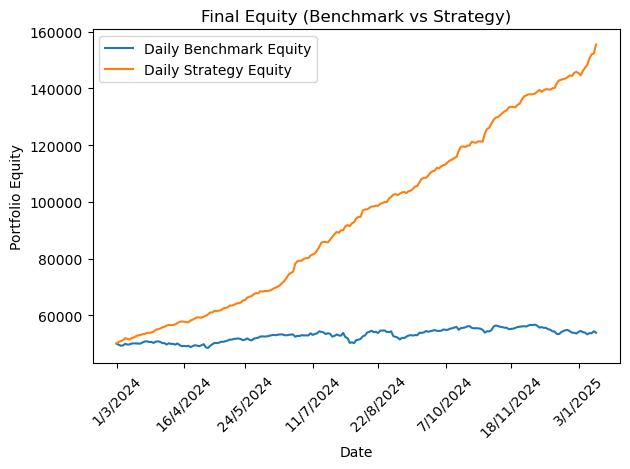

In [18]:
comparison=daily_investment_returns.join(portfolio_df)

# Plot and capture the line objects
lines = plt.plot(comparison[["benchmark_daily_final_equity", "strategy_daily_final_equity"]])

# Customize x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=45)

# Labels and title
plt.title("Final Equity (Benchmark vs Strategy)")
plt.xlabel("Date")
plt.ylabel("Portfolio Equity")

# Set legend with custom labels
plt.legend(lines, ["Daily Benchmark Equity", "Daily Strategy Equity"])

plt.tight_layout()
plt.show()


---- End of code ---
---